In [134]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
print('Libraries imported successfully')

Libraries imported successfully


In [135]:
from google.colab import files
uploaded = files.upload()

Saving AI-Based Hiring Prediction System.csv to AI-Based Hiring Prediction System (4).csv


In [136]:
df=pd.read_csv('AI-Based Hiring Prediction System.csv')
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [137]:
print(df.head())
print(df.info())
print(df.describe())

   Resume_ID              Name                                        Skills  \
0          1        Ashley Ali                      TensorFlow, NLP, Pytorch   
1          2      Wesley Roman  Deep Learning, Machine Learning, Python, SQL   
2          3     Corey Sanchez         Ethical Hacking, Cybersecurity, Linux   
3          4  Elizabeth Carney                   Python, Pytorch, TensorFlow   
4          5        Julie Hill                              SQL, React, Java   

   Experience (Years) Education                Certifications  \
0                  10      B.Sc                           NaN   
1                  10       MBA                     Google ML   
2                   1       MBA  Deep Learning Specialization   
3                   7    B.Tech                 AWS Certified   
4                   4       PhD                           NaN   

                Job Role Recruiter Decision  Salary Expectation ($)  \
0          AI Researcher               Hire              

In [138]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


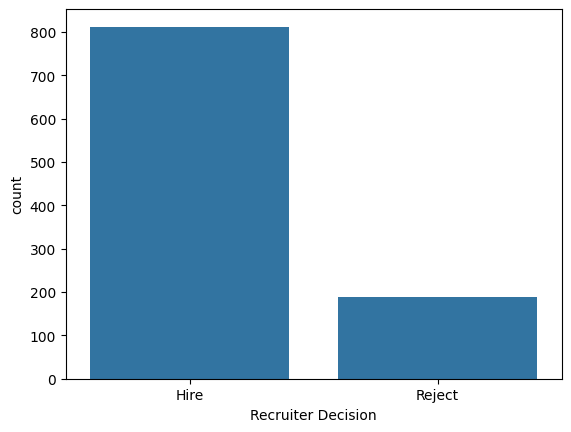

In [139]:
sns.countplot(x='Recruiter Decision',data=df)
plt.show()

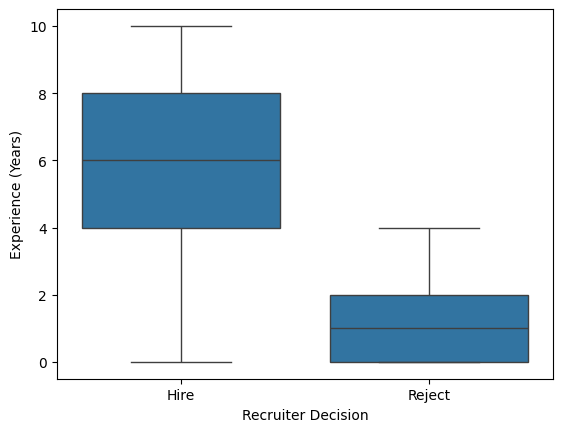

In [140]:
sns.boxplot(x='Recruiter Decision',y='Experience (Years)',data=df)
plt.show()

In [141]:
df['Recruiter Decision'] = df['Recruiter Decision'].map({
    'Hire': 1,
    'Reject': 0
})

In [142]:
print(df['Recruiter Decision'].unique())
print(df['Recruiter Decision'].value_counts())

[1 0]
Recruiter Decision
1    812
0    188
Name: count, dtype: int64


In [143]:
le = LabelEncoder()
for col in df.columns:
  if df[col].dtype=='object':
      df[col]=le.fit_transform(df[col])
print(df.head())

   Resume_ID  Name  Skills  Experience (Years)  Education  Certifications  \
0          1    60     226                  10          0               3   
1          2   964      32                  10          3               2   
2          3   181      46                   1          3               1   
3          4   277     152                   7          1               0   
4          5   483     221                   4          4               3   

   Job Role  Recruiter Decision  Salary Expectation ($)  Projects Count  \
0         0                   1                  104895               8   
1         2                   1                  113002               1   
2         1                   1                   71766               7   
3         0                   1                   46848               0   
4         3                   1                   87441               9   

   AI Score (0-100)  
0               100  
1               100  
2                70 

In [144]:
print(df.isnull().sum())

Resume_ID                 0
Name                      0
Skills                    0
Experience (Years)        0
Education                 0
Certifications            0
Job Role                  0
Recruiter Decision        0
Salary Expectation ($)    0
Projects Count            0
AI Score (0-100)          0
dtype: int64


In [145]:
X=df.drop(['Recruiter Decision','Resume_ID','Name'],axis=1)
y=df['Recruiter Decision']
print(X.head())
print(y.head())

   Skills  Experience (Years)  Education  Certifications  Job Role  \
0     226                  10          0               3         0   
1      32                  10          3               2         2   
2      46                   1          3               1         1   
3     152                   7          1               0         0   
4     221                   4          4               3         3   

   Salary Expectation ($)  Projects Count  AI Score (0-100)  
0                  104895               8               100  
1                  113002               1               100  
2                   71766               7                70  
3                   46848               0                95  
4                   87441               9               100  
0    1
1    1
2    1
3    1
4    1
Name: Recruiter Decision, dtype: int64


In [146]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 8)
(200, 8)
(800,)
(200,)


In [147]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
print(X_train)
print(X_test)

[[ 1.35029915  1.63991008 -0.70578467 ... -0.89440139 -0.38750221
   0.7687779 ]
 [ 0.98977233 -0.29794526  1.41156935 ...  1.2597954   1.48940054
   0.7687779 ]
 [-1.40412581 -0.62092115  0.70578467 ...  1.66960615  0.86376629
   0.7687779 ]
 ...
 [ 0.71577194  0.9939583  -0.70578467 ...  0.63837552  1.48940054
   0.7687779 ]
 [ 0.2542976   0.67098241  0.         ...  1.08629179 -0.07468509
   0.7687779 ]
 [-0.9282304  -0.94389704  0.70578467 ... -1.36101759 -0.70031934
  -1.43823999]]
[[-0.10622923  1.31693419 -1.41156935 ...  1.24255088  1.48940054
   0.7687779 ]
 [-1.50507332  0.34800652  0.70578467 ... -1.06331822  0.86376629
   0.7687779 ]
 [ 0.75903516  0.02503063  0.70578467 ... -0.13621621  0.23813204
   0.7687779 ]
 ...
 [-1.44738903 -1.26687293  0.         ...  0.97841436  0.23813204
  -0.70256736]
 [-0.79844074  0.67098241 -1.41156935 ...  1.57663574  1.17658341
   0.7687779 ]
 [ 1.56661525 -1.26687293  0.70578467 ... -0.21106004  0.23813204
  -1.68346419]]


In [149]:
lr_model=LogisticRegression()
lr_model.fit(X_train,y_train)
print('Model trained succesfully')

Model trained succesfully


In [148]:
lr_predictions=lr_model.predict(X_test)
print(lr_predictions)

[1 1 1 1 0 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1
 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 0 1 1 1 0 1 0 1
 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 0 1 1 1
 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 0 1 0 1
 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0]


In [150]:
lr_accuracy=accuracy_score(y_test,lr_predictions)
print(lr_accuracy)
lr_precision=classification_report(y_test,lr_predictions)
print(lr_precision)
lr_cm=confusion_matrix(y_test,lr_predictions)
print(lr_cm)
lr_recall=recall_score(y_test,lr_predictions)
print(lr_recall)
lr_f1=f1_score(y_test,lr_predictions)
print(lr_f1)

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00       154

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

[[ 46   0]
 [  0 154]]
1.0
1.0


In [151]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

In [152]:
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)
print('Model trained succesfully')
rf_predictions=rf_model.predict(X_test)
print(rf_predictions)
rf_accuracy=accuracy_score(y_test,rf_predictions)
print(rf_accuracy)
rf_precision=classification_report(y_test,rf_predictions)
print(rf_precision)
rf_cm=confusion_matrix(y_test,rf_predictions)
print(rf_cm)

Model trained succesfully
[1 1 1 1 0 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1
 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 0 1 1 1 0 1 0 1
 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 0 1 1 1
 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 0 1 0 1
 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0]
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00       154

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

[[ 46   0]
 [  0 154]]


In [153]:
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)
print('Model trained successfully')
knn_pred=knn.predict(X_test)
print(knn_pred)
knn_acc=accuracy_score(y_test,knn_pred)
print('Accuracy:',knn_acc)

Model trained successfully
[1 1 1 1 0 1 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 1 0 1
 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 0 1 1 1 0 1 0 1
 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1
 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 0 1 0 1
 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1]
Accuracy: 0.975


In [154]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'K-Nearest Neighbors'],
    'Accuracy': [lr_accuracy, dt_acc, rf_accuracy, knn_acc]
})
print(comparison_df)


                 Model  Accuracy
0  Logistic Regression     1.000
1        Decision Tree     1.000
2        Random Forest     1.000
3  K-Nearest Neighbors     0.975


In [155]:
best_model = comparison_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]
print(best_model)

Model       Logistic Regression
Accuracy                    1.0
Name: 0, dtype: object


In [156]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
grid_search = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


{'C': 10, 'solver': 'liblinear'}
Best Score: 1.0


In [157]:
best_model=grid_search.best_estimator_
best_predictions=best_model.predict(X_test)
best_accuracy=accuracy_score(y_test,best_predictions)
print(best_accuracy)

1.0


In [162]:
feature_importance = df.corr(
    numeric_only=True
)['Recruiter Decision']
feature_importance = feature_importance.drop(
    'Recruiter Decision'
             )
feature_importance = feature_importance.sort_values(
    ascending=False
           )
print("Feature importance:")
print(feature_importance)

Feature importance:
AI Score (0-100)          0.840543
Experience (Years)        0.576235
Projects Count            0.331249
Skills                    0.050019
Salary Expectation ($)    0.044073
Resume_ID                 0.034135
Education                 0.021014
Job Role                  0.019007
Name                      0.012907
Certifications           -0.036095
Name: Recruiter Decision, dtype: float64


In [163]:
#example
candidate_data = [[200, 5, 2, 1, 3, 70000, 6, 85]]
data_scaled = scaler.transform(candidate_data)
prediction = best_model.predict(data_scaled)
if prediction[0]==1:
    print("Hired")
else:
    print("Rejected")

Hired


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
